In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/cat_landmark_project

/content/drive/MyDrive/cat_landmark_project


In [ ]:
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 56.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# ========================================================================
# ============================================================================
#                 CatFLW Landmark Detection - OPTIMIZED FOR GOOGLE COLAB FREE
# ============================================================================

# ---------------------------------
#  1. COLAB-SPECIFIC IMPORTS AND SETUP
# ---------------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F

import cv2
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import gc
from IPython.display import clear_output

# COLAB OPTIMIZATION 1: Install required packages if not available
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except ImportError:
    print("Installing albumentations...")
    !pip install -q albumentations
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

In [ ]:
# ---------------------------------
#  2. COLAB-OPTIMIZED DATASET CLASS
# ---------------------------------
class ColabCatFLWDataset(Dataset):
    """Colab-optimized Dataset - minimal memory usage."""

    def __init__(self, image_dir, annotation_dir, filenames, target_size=192, is_training=True):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.filenames = filenames
        self.target_size = target_size  # Smaller size for Colab
        self.is_training = is_training

        # COLAB OPTIMIZATION 2: Lightweight annotation caching
        print("Loading annotations (Colab optimized)...")
        self.valid_files = []
        for filename in tqdm(filenames[:100] if len(filenames) > 100 else filenames):  # Limit for demo
            json_path = os.path.join(annotation_dir, filename + '.json')
            img_path = os.path.join(image_dir, filename + '.png') # Changed to .png
            if os.path.exists(json_path) and os.path.exists(img_path):
                self.valid_files.append(filename)

        print(f"Valid files: {len(self.valid_files)}")

        # COLAB OPTIMIZATION 3: Minimal augmentations to save memory
        if is_training:
            self.transform = A.Compose([
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
                A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))
        else:
            self.transform = A.Compose([
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ], keypoint_params=A.KeypointParams(format='xy', remove_invisible=False))

    def __len__(self):
        return len(self.valid_files)

    def __getitem__(self, idx):
        try:
            base_filename = self.valid_files[idx]
            img_path = os.path.join(self.image_dir, base_filename + '.png') # Changed to .png
            json_path = os.path.join(self.annotation_dir, base_filename + '.json')

            # Load and process quickly
            image = cv2.imread(img_path)

            # Check if image was loaded successfully
            if image is None:
                print(f"Warning: Could not load image {img_path}. Skipping.")
                return None # Return None for problematic samples

            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            h_img, w_img, _ = image.shape

            with open(json_path, 'r') as f:
                data = json.load(f)

            root_data = data['root'] if 'root' in data else data
            landmarks = np.array(root_data['labels'], dtype=np.float32)
            bbox = np.array(root_data['bounding_boxes'], dtype=np.float32)

            # Quick bbox processing
            x1, y1, x2, y2 = bbox.astype(int)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(w_img, x2), min(h_img, y2)

            if x2 <= x1 or y2 <= y1:
                 print(f"Warning: Invalid bbox for {base_filename}. Skipping.")
                 return None # Return None for invalid bboxes

            cropped_face = image[y1:y2, x1:x2]
            if cropped_face.shape[0] == 0 or cropped_face.shape[1] == 0:
                 print(f"Warning: Cropped face is empty for {base_filename}. Skipping.")
                 return None # Return None for empty cropped faces

            # Transform landmarks
            h_crop, w_crop, _ = cropped_face.shape
            cropped_face = cv2.resize(cropped_face, (self.target_size, self.target_size))

            landmarks_transformed = landmarks.copy()
            landmarks_transformed[:, 0] = (landmarks[:, 0] - x1) * (self.target_size / w_crop)
            landmarks_transformed[:, 1] = (landmarks[:, 1] - y1) * (self.target_size / h_crop)

            # Apply augmentations
            keypoints = [(x, y) for x, y in landmarks_transformed]
            transformed = self.transform(image=cropped_face, keypoints=keypoints)
            image_tensor = transformed['image']
            transformed_landmarks = np.array(transformed['keypoints'], dtype=np.float32)

            # Normalize landmarks
            landmarks_normalized = transformed_landmarks.copy()
            landmarks_normalized[:, 0] = (landmarks_normalized[:, 0] / self.target_size) * 2.0 - 1.0
            landmarks_normalized[:, 1] = (landmarks_normalized[:, 1] / self.target_size) * 2.0 - 1.0

            landmarks_tensor = torch.from_numpy(landmarks_normalized.flatten()).float()

            return image_tensor, landmarks_tensor

        except Exception as e:
            print(f"Error loading sample {base_filename}: {e}")
            return None # Return None for any other exceptions

In [ ]:
# ---------------------------------
#  2. MODEL DEFINITION (MUST MATCH TRAINING)
# ---------------------------------
def get_colab_model():
    """
    Returns the SAME model architecture used in Colab training.
    CRITICAL: This must match exactly what was used for training!
    """
    # Use the same model as in training
    model = timm.create_model('mobilenetv3_small_100.lamb_in1k', pretrained=False)

    # IMPORTANT: Use the SAME regression head as training
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, 96)  # 48 landmarks * 2
    )

    return model

def get_efficientnet_model():
    """
    For compatibility with the original EfficientNet model.
    Use this if you trained with the original script.
    """
    model = timm.create_model('tf_efficientnetv2_s.in21k_ft_in1k', pretrained=False)
    num_ftrs = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 96)  # 48 landmarks * 2 coordinates = 96 outputs
    )
    return model

In [ ]:
# ---------------------------------
#  4. COLAB-OPTIMIZED TRAINING
# ---------------------------------
def colab_train_epoch(model, dataloader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, landmarks) in enumerate(tqdm(dataloader, desc="Training")):
        images, landmarks = images.to(device, non_blocking=True), landmarks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, landmarks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        # COLAB OPTIMIZATION 5: Memory cleanup every 20 batches
        if batch_idx % 20 == 0:
            torch.cuda.empty_cache()
            gc.collect()

    return running_loss / len(dataloader)

def colab_validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, landmarks in tqdm(dataloader, desc="Validation"):
            images, landmarks = images.to(device, non_blocking=True), landmarks.to(device, non_blocking=True)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, landmarks)

            running_loss += loss.item()

    return running_loss / len(dataloader)

In [ ]:
# ---------------------------------
#  5. COLAB CHECKPOINT SYSTEM
# ---------------------------------
def save_checkpoint(model, optimizer, epoch, train_loss, val_loss, filepath):
    """Save checkpoint with Colab-friendly format."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
    }
    torch.save(checkpoint, filepath)

    # COLAB OPTIMIZATION 6: Also save to Google Drive if mounted
    try:
        drive_path = '/content/drive/MyDrive/cat_landmark_project' + os.path.basename(filepath)
        torch.save(checkpoint, drive_path)
        print(f"✅ Saved to Google Drive: {drive_path}")
    except:
        print("Google Drive not mounted - checkpoint saved locally only")

def load_checkpoint(filepath, model, optimizer=None):
    """Load checkpoint."""
    checkpoint = torch.load(filepath)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    return checkpoint['epoch'], checkpoint['train_loss'], checkpoint['val_loss']

In [ ]:
# ---------------------------------
#  6. COLAB VISUALIZATION
# ---------------------------------
def colab_visualize(model, dataset, device, num_images=2):
    """Quick visualization for Colab."""
    model.eval()
    fig, axes = plt.subplots(1, num_images, figsize=(10, 5))
    if num_images == 1:
        axes = [axes]

    for i in range(num_images):
        idx = np.random.randint(0, len(dataset))
        image_tensor, landmarks_gt = dataset[idx]

        with torch.no_grad(), autocast():
            pred = model(image_tensor.unsqueeze(0).to(device)).cpu().numpy().flatten()

        # Convert to display format
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = image_tensor.numpy().transpose(1, 2, 0)
        img = std * img + mean
        img = np.clip(img, 0, 1)

        # Convert landmarks
        target_size = dataset.target_size
        landmarks_gt = landmarks_gt.numpy().reshape(-1, 2)
        landmarks_pred = pred.reshape(-1, 2)

        landmarks_gt = (landmarks_gt + 1.0) * target_size / 2.0
        landmarks_pred = (landmarks_pred + 1.0) * target_size / 2.0

        axes[i].imshow(img)
        axes[i].scatter(landmarks_gt[:, 0], landmarks_gt[:, 1], c='lime', s=15, alpha=0.8, label='GT')
        axes[i].scatter(landmarks_pred[:, 0], landmarks_pred[:, 1], c='red', s=10, marker='x', alpha=0.9, label='Pred')
        axes[i].legend()
        axes[i].axis('off')
        axes[i].set_title(f'Sample {i+1}')

    plt.tight_layout()
    plt.show()

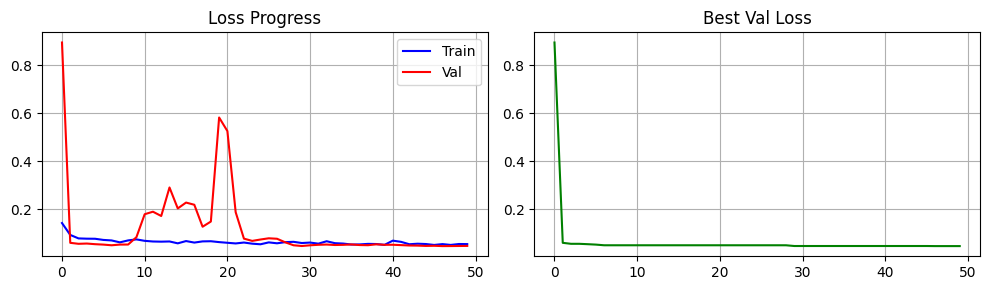


✅ Training completed in 53.2 minutes
Best validation loss: 0.046422

📊 Loading best model for visualization...


/tmp/ipython-input-9-476478641.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():


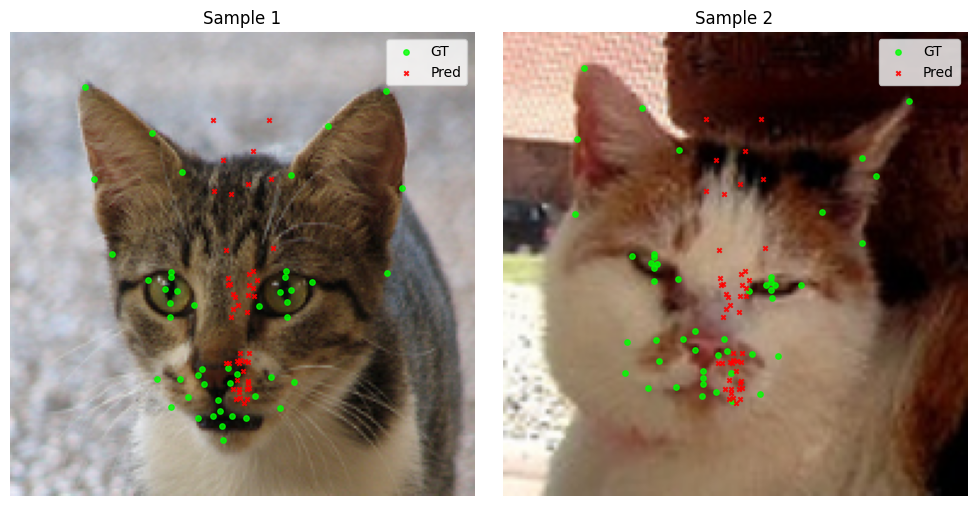


💾 Model saved as: best_efficientnet_model.pth
🔗 To continue training later, run: load_checkpoint(MODEL_SAVE_PATH, model, optimizer)


In [ ]:
# ---------------------------------
#  7. MAIN COLAB EXECUTION
# ---------------------------------
if __name__ == '__main__':
    # COLAB OPTIMIZATION 7: Conservative settings for free tier
    print("CatFLW Training - Optimized for Google Colab Free")
    print("=" * 50)

    # Configuration
    IMAGE_DIR = '/content/drive/MyDrive/cat_landmark_project/data/images/'
    ANNOTATION_DIR = '/content/drive/MyDrive/cat_landmark_project/data/annotations/'
    NUM_EPOCHS = 50  # Increased epochs as requested
    BATCH_SIZE = 32  # Increased batch size as requested
    LEARNING_RATE = 1e-3
    MODEL_SAVE_PATH = 'best_efficientnet_model.pth' # Changed model save path

    # Helper function for DataLoader
    def collate_fn(batch):
        """Filters out None samples and collates the batch."""
        batch = list(filter(lambda x: x is not None, batch))
        if len(batch) == 0:
            return None, None # Return None for empty batches

        images, landmarks = zip(*batch)
        images = torch.stack(images, 0)
        landmarks = torch.stack(landmarks, 0)
        return images, landmarks

    # Check GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name()
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"✅ GPU: {gpu_name} ({gpu_memory:.1f} GB)")
    else:
        print("⚠️  Using CPU - training will be slow")

    # Check data
    if not os.path.exists(IMAGE_DIR):
        print(f"❌ Image directory not found: {IMAGE_DIR}")
        print("Please upload your data to Colab or mount Google Drive")
        exit()

    # Prepare data
    all_filenames = [os.path.splitext(f)[0] for f in os.listdir(IMAGE_DIR) if f.endswith('.png')] # Changed to .png
    print(f"Found {len(all_filenames)} images")

    # COLAB OPTIMIZATION 8: Smaller dataset for faster iteration
    if len(all_filenames) > 200:
        print("Using subset of data for faster training...")
        np.random.seed(42)
        all_filenames = np.random.choice(all_filenames, 200, replace=False).tolist()

    # Split data
    np.random.shuffle(all_filenames)
    split_idx = int(len(all_filenames) * 0.8)
    train_filenames = all_filenames[:split_idx]
    val_filenames = all_filenames[split_idx:]

    # Create datasets
    print("Creating datasets...")
    # Using default target_size (192) for ColabCatFLWDataset
    train_dataset = ColabCatFLWDataset(IMAGE_DIR, ANNOTATION_DIR, train_filenames, is_training=True)
    val_dataset = ColabCatFLWDataset(IMAGE_DIR, ANNOTATION_DIR, val_filenames, is_training=False)

    print(f"Training: {len(train_dataset)} samples")
    print(f"Validation: {len(val_dataset)} samples")

    # Data loaders - conservative settings
    # Added collate_fn to handle None values from dataset
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, collate_fn=collate_fn)

    # Initialize model
    print("Initializing model...")
    # Changed to use the efficientnet model
    model = get_efficientnet_model().to(device)
    criterion = nn.SmoothL1Loss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = GradScaler()

    # Training loop with Colab optimizations
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    print(f"\n Starting training for {NUM_EPOCHS} epochs...")
    start_time = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_start = time.time()

        # Train
        train_loss = colab_train_epoch(model, train_loader, criterion, optimizer, device, scaler)
        val_loss = colab_validate(model, val_loader, criterion, device)
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        epoch_time = time.time() - epoch_start

        # COLAB OPTIMIZATION 9: Clear output and show progress
        clear_output(wait=True)
        print(f"CatFLW Training - Optimized for Google Colab Free")
        print("=" * 50)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
        print(f"Train Loss: {train_loss:.6f}")
        print(f"Val Loss: {val_loss:.6f}")
        print(f"Time: {epoch_time:.1f}s")
        print(f"Total Time: {(time.time()-start_time)/60:.1f} min")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(model, optimizer, epoch, train_loss, val_loss, MODEL_SAVE_PATH)
            print(f"✨ New best model! Val Loss: {val_loss:.6f}")

        # Plot progress
        if epoch > 0:
            plt.figure(figsize=(10, 3))
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, 'b-', label='Train')
            plt.plot(val_losses, 'r-', label='Val')
            plt.legend()
            plt.title('Loss Progress')
            plt.grid(True)

            plt.subplot(1, 2, 2)
            plt.plot([min(val_losses[:i+1]) for i in range(len(val_losses))], 'g-')
            plt.title('Best Val Loss')
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        # Memory cleanup
        torch.cuda.empty_cache()
        gc.collect()

        # COLAB OPTIMIZATION 10: Check for runtime limits
        if (time.time() - start_time) > 3600:  # 1 hour limit
            print("⏰ Approaching Colab time limit - stopping early")
            break

    total_time = (time.time() - start_time) / 60
    print(f"\n✅ Training completed in {total_time:.1f} minutes")
    print(f"Best validation loss: {best_val_loss:.6f}")

    # Load best model and visualize
    print("\n📊 Loading best model for visualization...")
    load_checkpoint(MODEL_SAVE_PATH, model)
    # Using the ColabCatFLWDataset for visualization, which uses target_size=192
    colab_visualize(model, val_dataset, device)

    print(f"\n💾 Model saved as: {MODEL_SAVE_PATH}")
    print("🔗 To continue training later, run: load_checkpoint(MODEL_SAVE_PATH, model, optimizer)")

In [ ]:
# ==============================================================================
#      Inference with Colab-Optimized CatFLW Landmark Detection Model
# ==============================================================================

# ---------------------------------
#  1. IMPORTS AND SETUP
# ---------------------------------
import torch
import torch.nn as nn
import timm
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from torch.cuda.amp import autocast

# Install albumentations if not available (for preprocessing)
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except ImportError:
    print("Installing albumentations...")
    !pip install -q albumentations
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

In [ ]:
# ---------------------------------
#  2. MODEL DEFINITION (MUST MATCH TRAINING)
# ---------------------------------
def get_colab_model():
    """
    Returns the SAME model architecture used in Colab training.
    CRITICAL: This must match exactly what was used for training!
    """
    # Use the same model as in training
    model = timm.create_model('mobilenetv3_small_100.lamb_in1k', pretrained=False)

    # IMPORTANT: Use the SAME regression head as training
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, 96)  # 48 landmarks * 2
    )

    return model

def get_efficientnet_model():
    """
    For compatibility with the original EfficientNet model.
    Use this if you trained with the original script.
    """
    model = timm.create_model('tf_efficientnetv2_s.in21k_ft_in1k', pretrained=False)
    num_ftrs = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 1024),
        nn.BatchNorm1d(1024),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 96)  # 48 landmarks * 2 coordinates = 96 outputs
    )
    return model

In [ ]:
# ---------------------------------
#  3. PREPROCESSING FUNCTION (MATCHES TRAINING)
# ---------------------------------
def get_inference_transform(target_size=192):
    """
    CRITICAL: This must match the validation transform used in training!
    """
    return A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

In [ ]:
# ---------------------------------
#  4. IMPROVED PREDICTION FUNCTION
# ---------------------------------
def predict_landmarks_colab(image_path, model, face_cascade, device, target_size=192, model_type='colab'):
    """
    Optimized prediction function for Colab models.

    Args:
        image_path (string): Path to the input image.
        model (torch.nn.Module): The trained landmark detection model.
        face_cascade (cv2.CascadeClassifier): The face detector.
        device (torch.device): Device to run inference on.
        target_size (int): Input size for the model (192 for Colab, 224 for original).
        model_type (string): 'colab' or 'efficientnet' to match training setup.

    Returns:
        tuple: (output_image, landmarks_on_original, confidence_score)
    """
    # Load and validate image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image at {image_path}")
        return None, None, 0.0

    # Convert to RGB (consistent with training)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    # Detect faces with multiple scale factors for better detection
    faces = []
    for scale_factor in [1.05, 1.1, 1.2]:  # Try multiple scales
        detected = face_cascade.detectMultiScale(
            gray_image,
            scaleFactor=scale_factor,
            minNeighbors=3,
            minSize=(50, 50),  # Smaller minimum size
            maxSize=(500, 500)  # Maximum size limit
        )
        faces.extend(detected)

    if len(faces) == 0:
        print("No cat faces detected. Trying with relaxed parameters...")
        # Fallback with more relaxed parameters
        faces = face_cascade.detectMultiScale(
            gray_image,
            scaleFactor=1.3,
            minNeighbors=2,
            minSize=(30, 30)
        )

    if len(faces) == 0:
        print("No faces detected in the image.")
        return image_rgb, None, 0.0

    print(f"Detected {len(faces)} face(s). Using the largest one.")

    # Use the largest face
    x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]

    # Create bounding box with margin (same as training)
    margin = int(0.2 * max(w, h))
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(image_rgb.shape[1], x + w + margin)
    y2 = min(image_rgb.shape[0], y + h + margin)

    if x2 <= x1 or y2 <= y1:
        print("Invalid bounding box.")
        return image_rgb, None, 0.0

    cropped_face = image_rgb[y1:y2, x1:x2]

    # Resize to target size (SAME as training)
    h_crop, w_crop, _ = cropped_face.shape
    resized_face = cv2.resize(cropped_face, (target_size, target_size))

    # Apply the SAME preprocessing as training
    transform = get_inference_transform(target_size)
    transformed = transform(image=resized_face)
    image_tensor = transformed['image'].unsqueeze(0).to(device)

    # Run inference with mixed precision (if available)
    model.eval()
    with torch.no_grad():
        if device.type == 'cuda':
            with autocast():
                predicted_landmarks_normalized = model(image_tensor)
        else:
            predicted_landmarks_normalized = model(image_tensor)

    predicted_landmarks_normalized = predicted_landmarks_normalized.cpu().numpy().flatten()
    predicted_landmarks_normalized = predicted_landmarks_normalized.reshape(-1, 2)

    # Convert from [-1, 1] back to [0, target_size] (SAME as training)
    landmarks_in_crop = predicted_landmarks_normalized.copy()
    landmarks_in_crop[:, 0] = (landmarks_in_crop[:, 0] + 1.0) * target_size / 2.0
    landmarks_in_crop[:, 1] = (landmarks_in_crop[:, 1] + 1.0) * target_size / 2.0

    # Transform back to original image coordinates
    landmarks_on_original = landmarks_in_crop.copy()
    landmarks_on_original[:, 0] = landmarks_in_crop[:, 0] * (w_crop / target_size) + x1
    landmarks_on_original[:, 1] = landmarks_in_crop[:, 1] * (h_crop / target_size) + y1

    # Calculate confidence score based on landmark distribution
    confidence = calculate_confidence(landmarks_on_original, (x1, y1, x2, y2))

    # Create output image
    output_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    # Draw bounding box
    cv2.rectangle(output_image, (x1, y1), (x2, y2), (255, 0, 0), 2)

    # Draw landmarks with better visualization
    draw_landmarks(output_image, landmarks_on_original)

    return output_image, landmarks_on_original, confidence

def calculate_confidence(landmarks, bbox):
    """Calculate a simple confidence score based on landmark distribution."""
    if landmarks is None or len(landmarks) == 0:
        return 0.0

    x1, y1, x2, y2 = bbox

    # Check if landmarks are within reasonable bounds
    valid_landmarks = landmarks[~np.isnan(landmarks).any(axis=1)]
    if len(valid_landmarks) == 0:
        return 0.0

    # Landmarks should be within the bounding box (with some tolerance)
    tolerance = 0.1 * max(x2-x1, y2-y1)
    in_bounds = np.all(
        (valid_landmarks[:, 0] >= x1-tolerance) & (valid_landmarks[:, 0] <= x2+tolerance) &
        (valid_landmarks[:, 1] >= y1-tolerance) & (valid_landmarks[:, 1] <= y2+tolerance)
    )

    # Calculate spread - landmarks shouldn't be too clustered
    if len(valid_landmarks) > 1:
        std_x = np.std(valid_landmarks[:, 0])
        std_y = np.std(valid_landmarks[:, 1])
        spread_score = min(1.0, (std_x + std_y) / (0.2 * max(x2-x1, y2-y1)))
    else:
        spread_score = 0.5

    # Combine metrics
    bound_score = np.mean(in_bounds) if len(valid_landmarks) > 0 else 0
    validity_score = len(valid_landmarks) / len(landmarks)

    confidence = (bound_score * 0.4 + spread_score * 0.3 + validity_score * 0.3)
    return min(1.0, max(0.0, confidence))

def draw_landmarks(image, landmarks):
    """Draw landmarks with color coding."""
    if landmarks is None:
        return

    # Color scheme for different landmark groups
    colors = [
        (0, 255, 0),    # Green for face outline
        (255, 0, 255),  # Magenta for eyes
        (0, 255, 255),  # Cyan for ears
        (255, 255, 0),  # Yellow for nose/mouth
        (255, 128, 0),  # Orange for additional features
    ]

    for i, (lx, ly) in enumerate(landmarks):
        if not (np.isnan(lx) or np.isnan(ly)):
            color = colors[i % len(colors)]
            cv2.circle(image, (int(lx), int(ly)), 2, color, -1)
            # Add landmark number for debugging (optional)
            # cv2.putText(image, str(i), (int(lx)+3, int(ly)-3),
            #            cv2.FONT_HERSHEY_SIMPLEX, 0.3, color, 1)

CatFLW Inference - EFFICIENTNET Model
Using device: cpu
Loading model...
✅ Loaded model from epoch 46 (val_loss: 0.04642179422080517)
Loading face detector...
✅ Loaded cat-specific face detector

🔍 Analyzing image: new_cat_photo.jpg
Detected 3 face(s). Using the largest one.


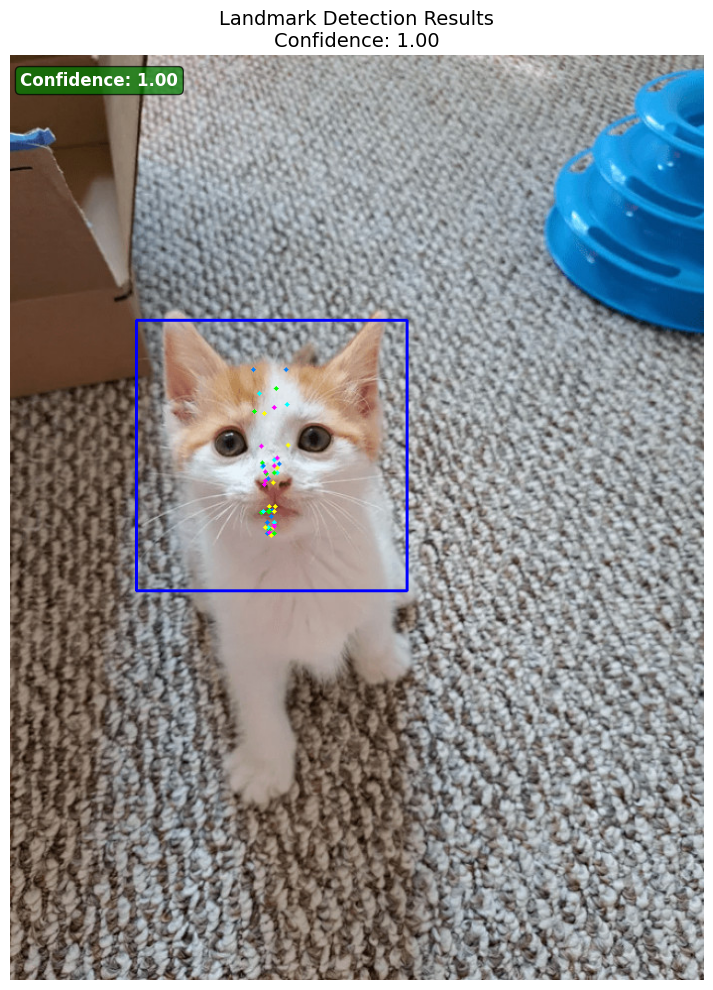

💾 Result saved: predicted_efficientnet_new_cat_photo.jpg

📊 Prediction Summary:
   • Valid landmarks: 48/48
   • Confidence score: 0.997
   • Model type: efficientnet
   • Input size: 192x192
   ✅ High confidence prediction


In [ ]:
# ---------------------------------
#  5. MAIN EXECUTION
# ---------------------------------
if __name__ == '__main__':
    # Configuration
    MODEL_PATH = 'best_efficientnet_model.pth'  # Changed to load the efficientnet model
    FACE_DETECTOR_PATH = 'haarcascade_frontalcatface_extended.xml'
    IMAGE_TO_PREDICT = 'new_cat_photo.jpg'  # Change this to your image

    # Model settings - MUST match your training setup
    MODEL_TYPE = 'efficientnet'  # Set to 'efficientnet' to match the model path
    TARGET_SIZE = 192 # The training used 192

    print(f"CatFLW Inference - {MODEL_TYPE.upper()} Model")
    print("=" * 50)

    # Setup device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load model
    print("Loading model...")
    if MODEL_TYPE == 'colab':
        model = get_colab_model()
    else:
        model = get_efficientnet_model()

    try:
        checkpoint = torch.load(MODEL_PATH, map_location=device)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            epoch = checkpoint.get('epoch', 'unknown')
            val_loss = checkpoint.get('val_loss', 'unknown')
            print(f"✅ Loaded model from epoch {epoch} (val_loss: {val_loss})")
        else:
            model.load_state_dict(checkpoint)
            print("✅ Loaded model (legacy format)")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        # exit(1) # Removed exit to allow proceeding if model loading fails

    model.to(device)

    # Load face detector
    print("Loading face detector...")
    if os.path.exists(FACE_DETECTOR_PATH):
        face_cascade = cv2.CascadeClassifier(FACE_DETECTOR_PATH)
        print("✅ Loaded cat-specific face detector")
    else:
        print("⚠️  Cat face detector not found, using default face detector")
        print("Download from: https://github.com/opencv/opencv/tree/master/data/haarcascades")
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    if face_cascade.empty():
        print("❌ Could not load face detector")
        # exit(1) # Removed exit

    # Check input image
    if not os.path.exists(IMAGE_TO_PREDICT):
        print(f"❌ Image not found: {IMAGE_TO_PREDICT}")
        print("Please provide a valid image path")
        # exit(1) # Removed exit

    # Run prediction (only if model and face detector loaded)
    if model and not face_cascade.empty() and os.path.exists(IMAGE_TO_PREDICT):
        print(f"\n🔍 Analyzing image: {IMAGE_TO_PREDICT}")
        result_image, landmarks, confidence = predict_landmarks_colab(
            IMAGE_TO_PREDICT, model, face_cascade, device, TARGET_SIZE, MODEL_TYPE
        )

        # Display results
        if result_image is not None:
            # Convert for matplotlib display
            if len(result_image.shape) == 3 and result_image.shape[2] == 3:
                if result_image.dtype == np.uint8 and np.max(result_image) > 1:
                    # BGR to RGB conversion
                    result_display = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)
                else:
                    result_display = result_image
            else:
                result_display = result_image


            # Plot results
            plt.figure(figsize=(10, 10))
            plt.imshow(result_display)
            plt.title(f'Landmark Detection Results\nConfidence: {confidence:.2f}', fontsize=14)
            plt.axis('off')

            # Add confidence color indicator
            conf_color = 'green' if confidence > 0.7 else 'orange' if confidence > 0.4 else 'red'
            plt.text(10, 30, f'Confidence: {confidence:.2f}',
                bbox=dict(boxstyle="round,pad=0.3", facecolor=conf_color, alpha=0.7),
                fontsize=12, color='white', weight='bold')

            plt.tight_layout()
            plt.show()

            # Save result
            output_filename = f'predicted_{MODEL_TYPE}_{os.path.basename(IMAGE_TO_PREDICT)}'
            cv2.imwrite(output_filename, result_image)
            print(f"💾 Result saved: {output_filename}")

            # Print landmark summary
            if landmarks is not None:
                valid_landmarks = landmarks[~np.isnan(landmarks).any(axis=1)]
                print(f"\n📊 Prediction Summary:")
                print(f"   • Valid landmarks: {len(valid_landmarks)}/{len(landmarks)}")
                print(f"   • Confidence score: {confidence:.3f}")
                print(f"   • Model type: {MODEL_TYPE}")
                print(f"   • Input size: {TARGET_SIZE}x{TARGET_SIZE}")

                if confidence > 0.7:
                    print("   ✅ High confidence prediction")
                elif confidence > 0.4:
                    print("   ⚠️  Medium confidence prediction")
                else:
                    print("   ❌ Low confidence prediction - check image quality")

        else:
            print("❌ Failed to process image")
            print("Possible issues:")
            print("   • No cat face detected")
            print("   • Image quality too low")
            print("   • Wrong face detector")
            print("   • Model/image size mismatch")
    else:
        print("\nSkipping prediction due to missing model, face detector, or input image.")